# Wide-Angle Tilt-Aware Iterative MF With Residual Line Cleanup

This notebook first performs wide-angle tilted destriping, then removes remaining thin high-alpha diagonal line artifacts using the final plume/high mask.


ROI table shape: (3335334, 187)
Cube shape: (1894, 1761, 185)
Wavelength range: 405.00 - 2474.76 nm
Valid pixels: 1562216 / 3335334
Selected cube shape: (1894, 1761, 29)
Selected wavelength range: 2100.05 - 2449.78 nm
Metadata-derived direction slopes:
  y_minus_x: 1.01578507
  y_plus_x : 1.22945318
Raw observation-edge slopes:
  observation_ul_to_ll: 1.01661154
  observation_ur_to_lr: 1.01495859
  observation_ul_to_ur: -1.23132077
  observation_ll_to_lr: -1.22758559

Running experiment: baseline_no_destripe
iter 01 | bg= 1562216 | thr=+1.063857e-01 | med=+1.218057e-04 | rstd=3.542131e-02 | plume=    9799 | destripe=False | directions=[]
iter 02 | bg= 1552417 | thr=+1.036075e-01 | med=+7.356415e-04 | rstd=3.429063e-02 | plume=   12681 | destripe=False | directions=[]
iter 03 | bg= 1549535 | thr=+1.033302e-01 | med=+9.055882e-04 | rstd=3.414155e-02 | plume=   13688 | destripe=False | directions=[]
iter 04 | bg= 1548528 | thr=+1.032974e-01 | med=+9.773625e-04 | rstd=3.410668e-02 | plume=

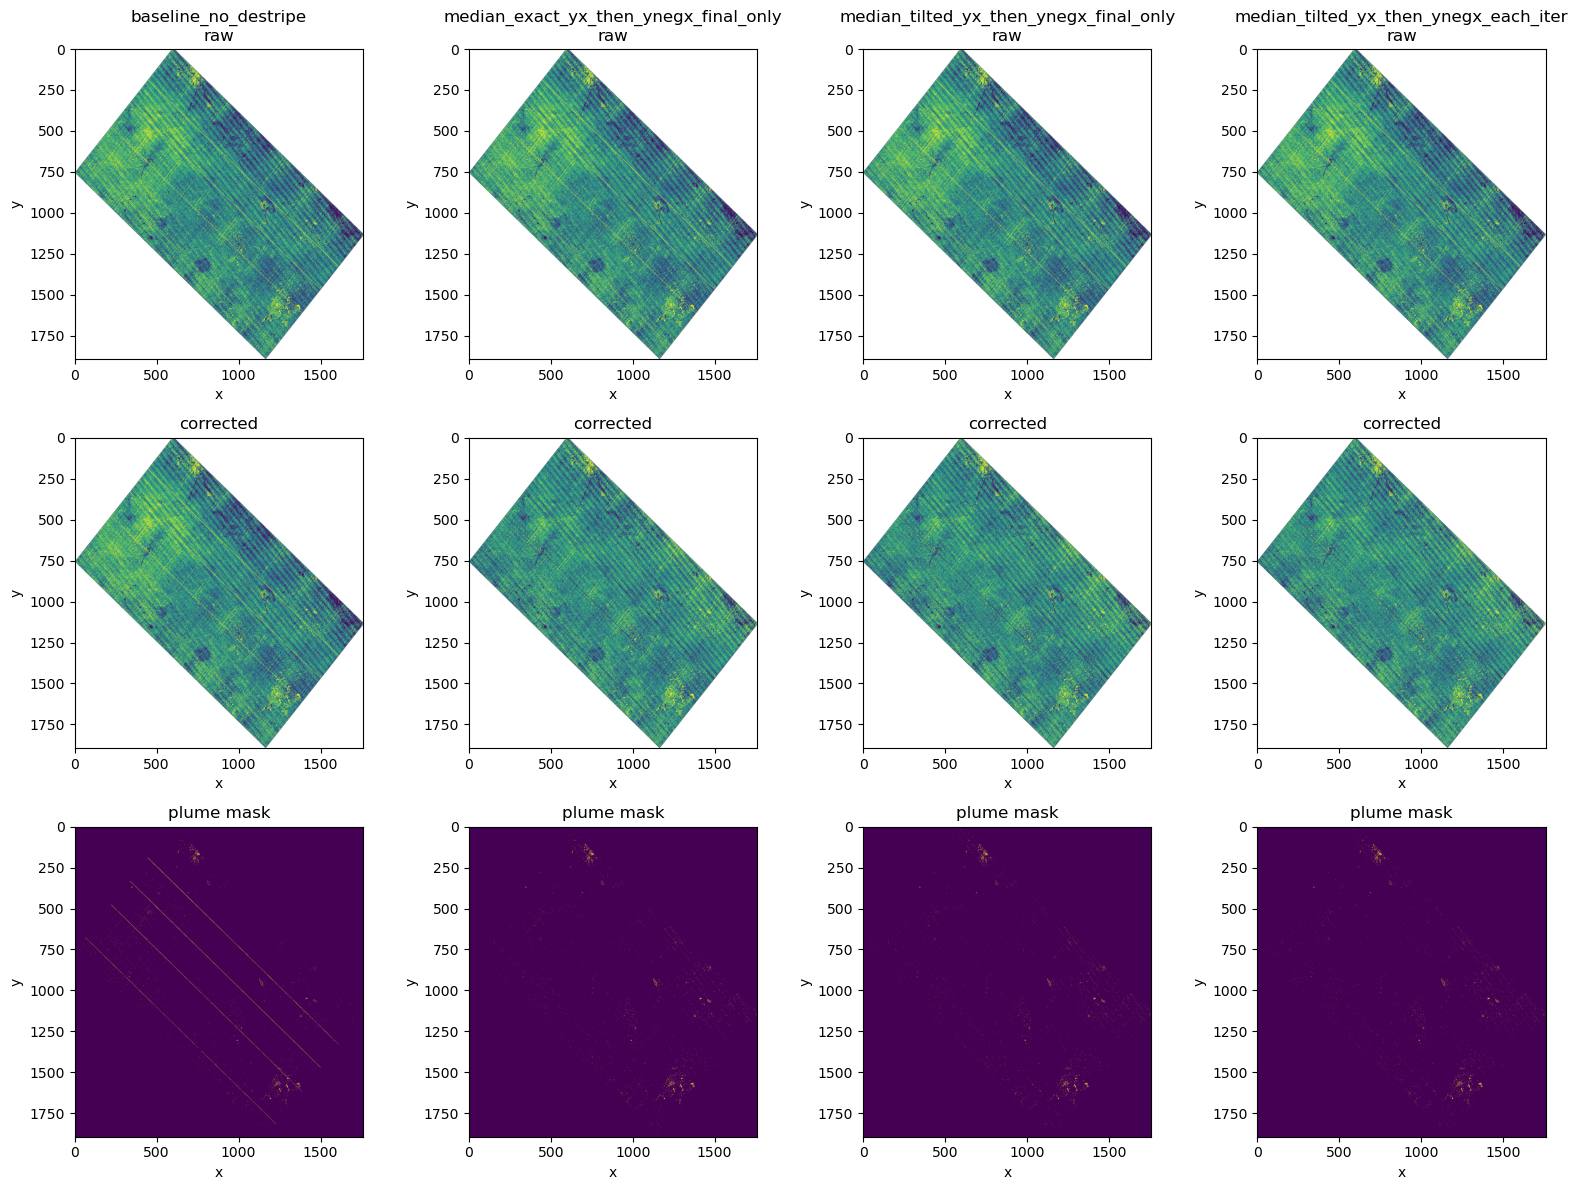

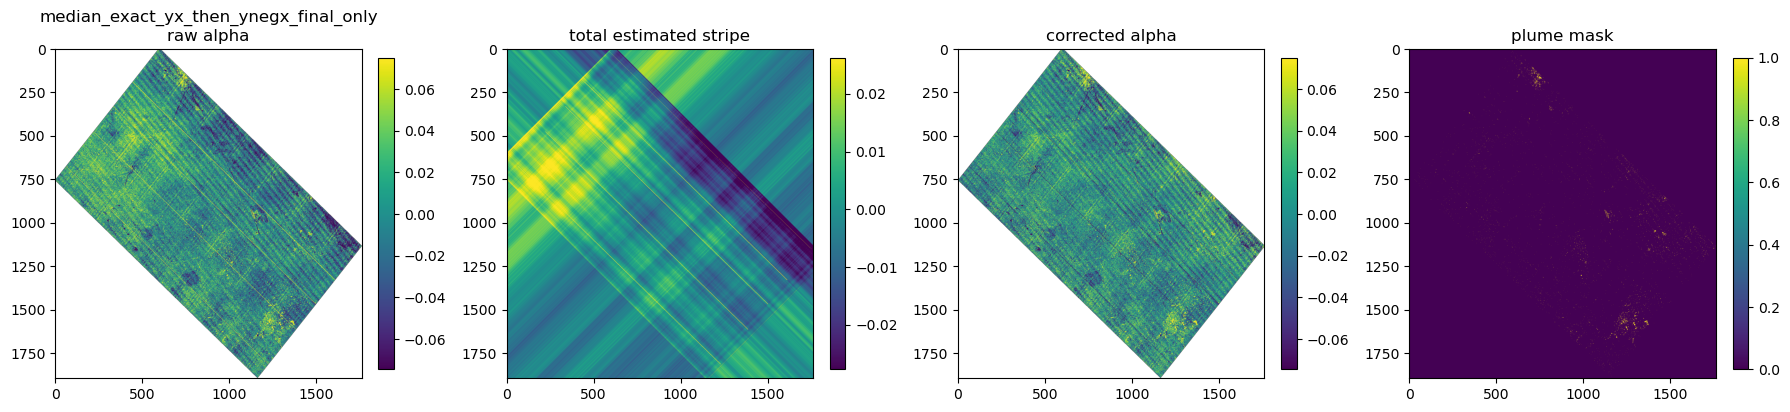

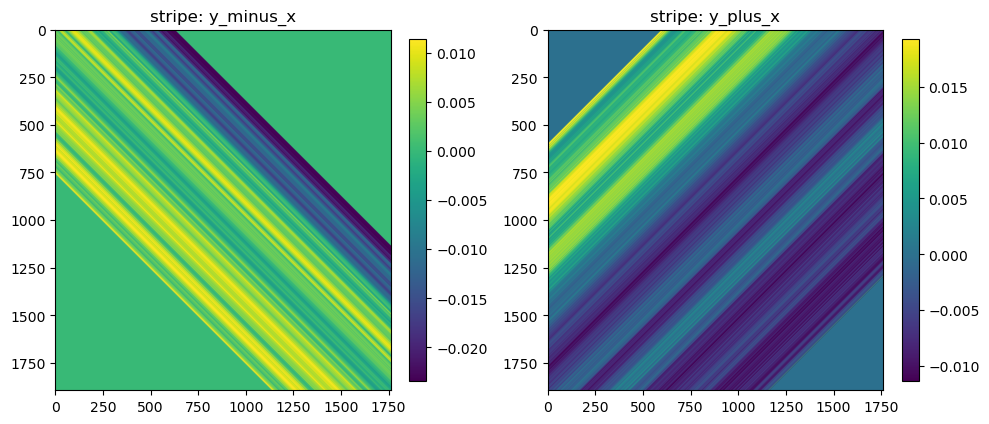

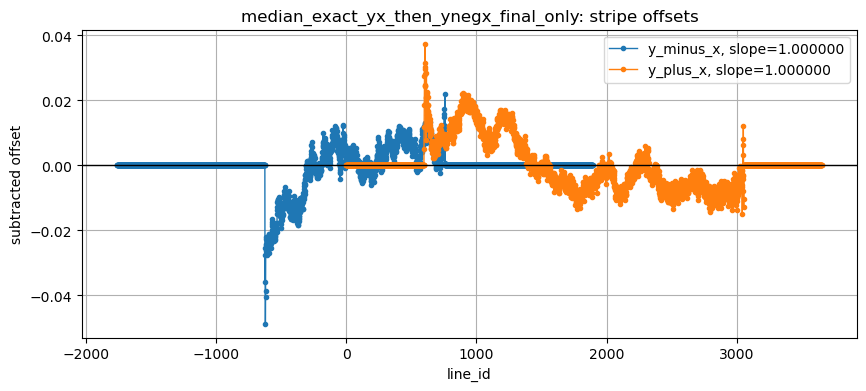

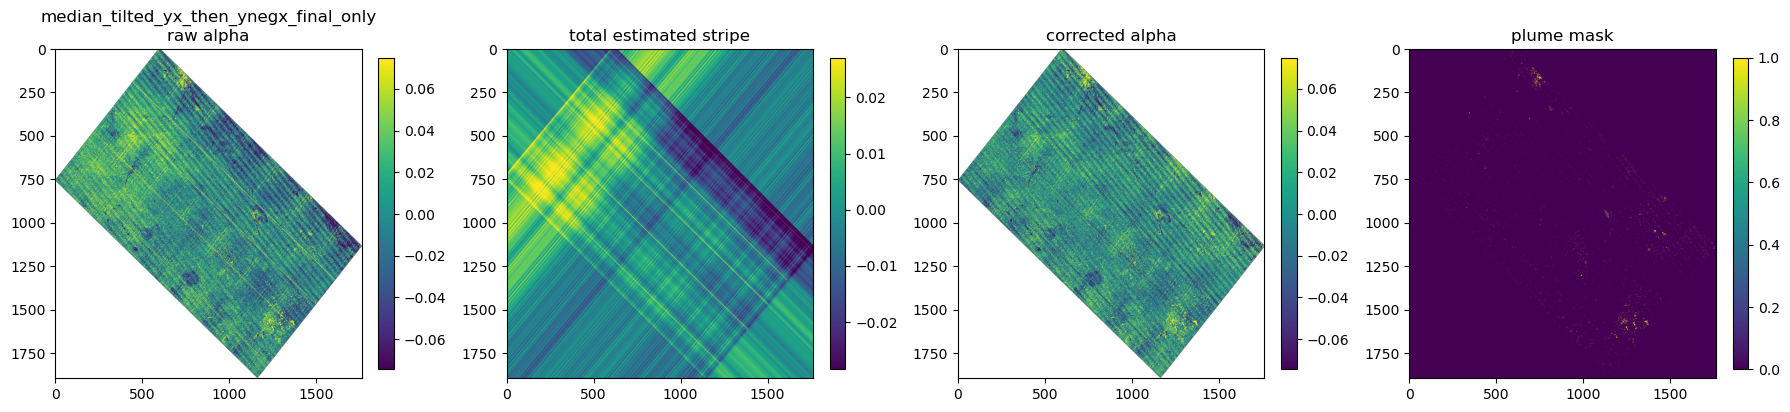

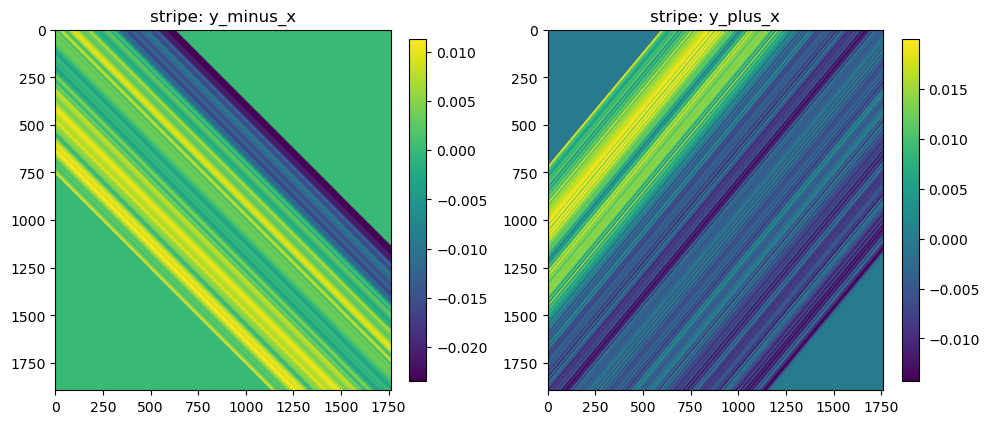

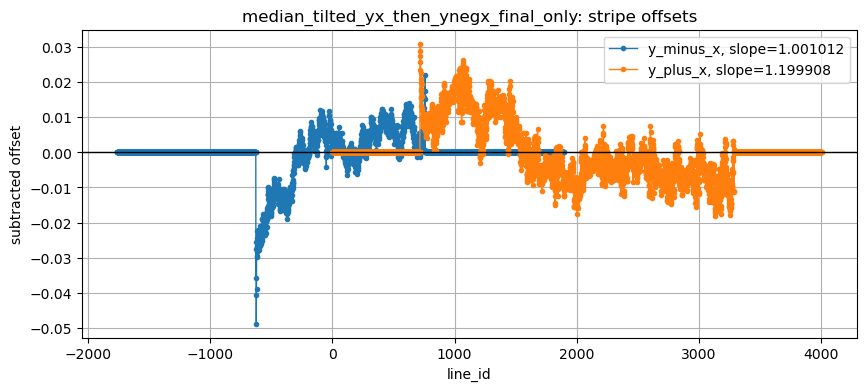

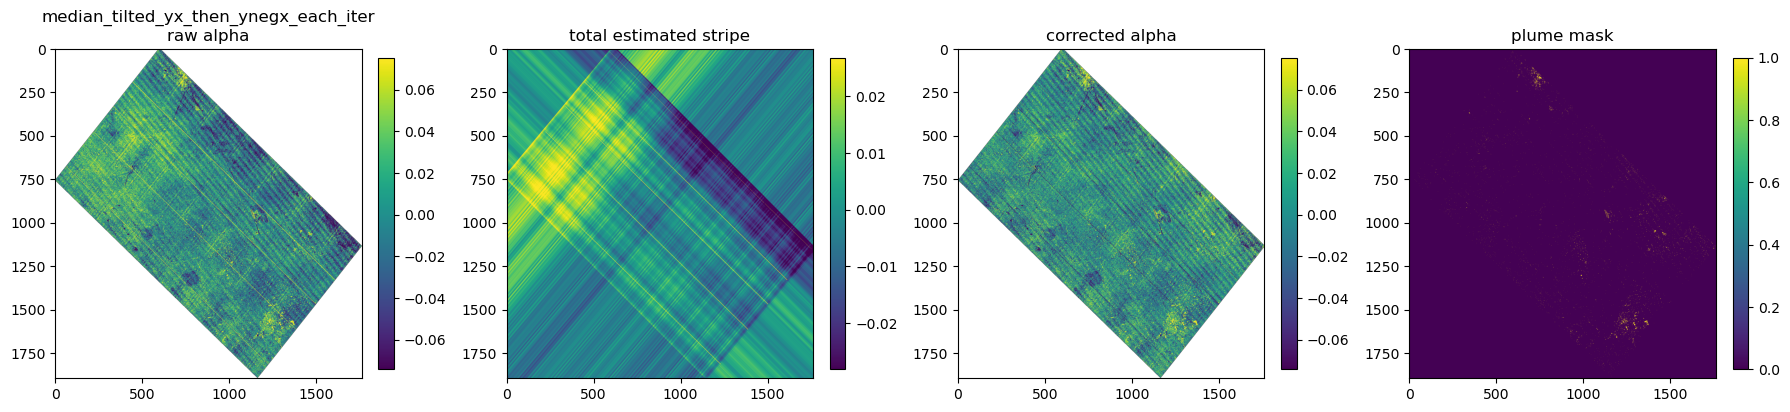

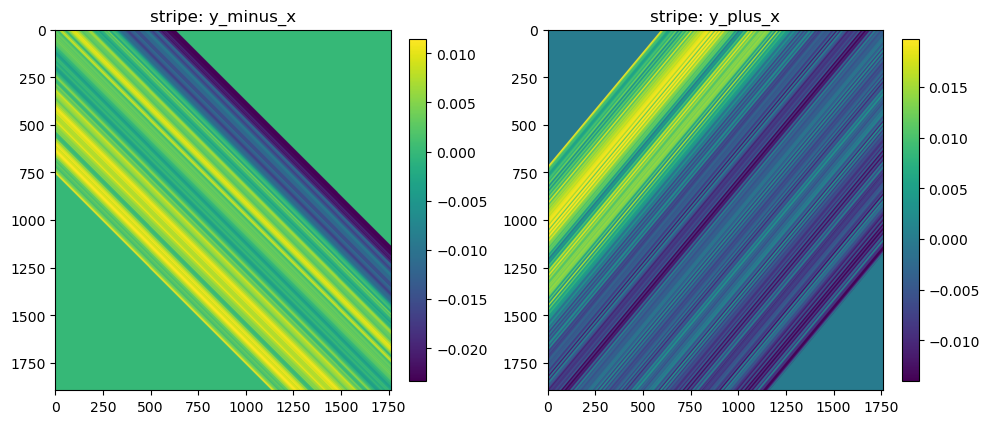

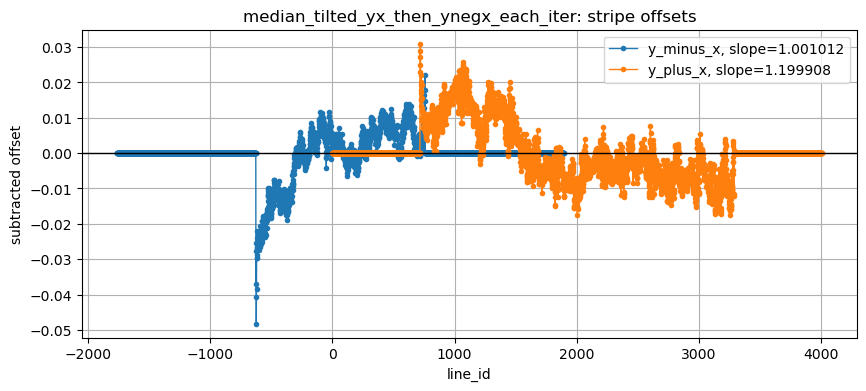

In [2]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Optional, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# 0. User settings
# ============================================================

ROI_CSV = Path(r"E:\refit\all_map_spectra.csv")
MODTRAN_CSV = Path(r"E:/refit/CH4c.csv")
METADATA_TXT = Path(
    r"E:/メタン/2025_HISUI_72_The Permian Basin-論文照合用/"
    r"HSHL1G_N320W1032_20221030160051_20231127193053/"
    r"HSHL1G_N320W1032_20221030160051_20231127193053.txt"
)
OUTPUT_DIR = Path("outputs_wide_angle_tilted_two_direction_diagonal_destripe")

WL_MIN = 2100.0
WL_MAX = 2450.0
FWHM_NM = 12.5

UAS_ALPHA_MIN = 0.0
UAS_ALPHA_MAX = 0.5

N_ITER = 5
NSIGMA = 3.0
REG = 1e-6
RCOND = 1e-8

NODATA_VALUES = [0, -9999]
REQUIRE_POSITIVE = True
MIN_VALID_FRACTION = 1.0

RUN_PLOTS = True
USE_METADATA_DIRECTION_SLOPES = True


RESIDUAL_LINE_CLEANUP_PARAMS = {
    # This removes remaining thin high-alpha diagonal lines after the normal
    # median tilted destriping. It is intentionally applied only at the end.
    "enabled": True,

    # The residual lines in the current result are y=x-ish. Start with only
    # y_minus_x to avoid unnecessary cross-track overcorrection.
    "directions": ["y_minus_x"],

    # Search around this base slope. For the provided result, the residual line
    # concentration is near slope=0.97727.
    "direction_slopes": {"y_minus_x": 1.0, "y_plus_x": 1.2},
    "slope_search_pixel_drift": 100.0,
    "slope_search_step_pixel_drift": 2.0,
    "line_bin_width": 1.0,

    # Use the final plume/high mask to find artifact lines.
    "threshold_nsigma": NSIGMA,
    "min_valid_pixels_per_line": 100,
    "min_high_pixels_per_line": 80,

    # For selected artifact lines, subtract line q90 - global background median.
    # q75 is milder; q90 removes the current long residual lines more completely.
    "offset_stat": "q90",
    "global_stat": "background_median",
    "offset_clip_min": 0.0,
    "offset_clip_max": None,
}


DEFAULT_DESTRIPE_PARAMS = {
    # y=x-ish stripes:  row - slope * col = const
    # y=-x-ish stripes: row + slope * col = const
    "directions": ["y_minus_x", "y_plus_x"],
    # Wide-angle defaults from this HISUI metadata. These are replaced
    # automatically from METADATA_TXT when USE_METADATA_DIRECTION_SLOPES=True.
    "direction_slopes": {"y_minus_x": 1.017, "y_plus_x": 1.23},
    "use_metadata_direction_slopes": True,

    # auto_slope searches around direction_slopes. The drift values below
    # mean +/-60 pixels of line drift across the image width, with 2-pixel steps.
    # This is intentionally wider than the previous +/-2 px search.
    "auto_slope": True,
    "slope_search_pixel_drift": 60.0,
    "slope_search_step_pixel_drift": 2.0,
    "slope_search_sample_step": 4,
    "slope_search_metric": "offset_abs_p99",

    # 1.0 means roughly one-pixel-wide tilted line bins.
    "line_bin_width": 1.0,

    # Start with median for large images. Other methods are implemented below.
    "method": "median",
    "min_pixels_per_line": 5,
    "preserve_global_stat": True,
    "smooth_half_window": 0,
    "exclude_mode": "robust_high",
    "exclude_nsigma": NSIGMA,
    "recompute_exclude_each_direction": True,
    "fallback_to_valid": True,
    "trim_fraction": 0.1,
    "mode_bins": 64,
    "sigma_clip_nsigma": 3.0,
    "sigma_clip_max_iter": 3,
    "threshold_source": "corrected",
}


EXPERIMENTS = {
    "baseline_no_destripe": {
        "destripe_when": "none",
        "destripe_params": None,
    },
    "median_exact_yx_then_ynegx_final_only": {
        "destripe_when": "final_only",
        "destripe_params": {
            **DEFAULT_DESTRIPE_PARAMS,
            "method": "median",
            "auto_slope": False,
            "direction_slopes": {"y_minus_x": 1.0, "y_plus_x": 1.0},
            "use_metadata_direction_slopes": False,
        },
    },
    "median_tilted_yx_then_ynegx_final_only": {
        "destripe_when": "final_only",
        "destripe_params": {**DEFAULT_DESTRIPE_PARAMS, "method": "median", "auto_slope": True},
    },
    "median_tilted_yx_then_ynegx_each_iter": {
        "destripe_when": "each_iter",
        "destripe_params": {**DEFAULT_DESTRIPE_PARAMS, "method": "median", "auto_slope": True},
    },
}

# Set to None to run all experiments. For a first large-image test, you may use:
# RUN_EXPERIMENT_NAMES = ["baseline_no_destripe", "median_tilted_yx_then_ynegx_final_only"]
RUN_EXPERIMENT_NAMES = None


# ============================================================
# 1. Data loading helpers
# ============================================================

def get_wave_columns(df: pd.DataFrame) -> tuple[list[str], np.ndarray]:
    wave_cols: list[str] = []
    wavelengths: list[float] = []
    pattern = re.compile(r"^wave_([0-9]+(?:\.[0-9]+)?)nm$")

    for col in df.columns:
        match = pattern.match(str(col))
        if match is not None:
            wave_cols.append(str(col))
            wavelengths.append(float(match.group(1)))

    if not wave_cols:
        raise ValueError("No wavelength columns found. Expected columns like wave_2300.0nm.")

    wavelengths_arr = np.asarray(wavelengths, dtype=float)
    order = np.argsort(wavelengths_arr)
    return [wave_cols[i] for i in order], wavelengths_arr[order]


def load_roi_spectra_csv(path: str | Path) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    df = pd.read_csv(path)
    if "y" not in df.columns or "x" not in df.columns:
        raise ValueError("The CSV file must contain y and x columns.")

    wave_cols, wavelengths = get_wave_columns(df)
    spectra = df[wave_cols].to_numpy(dtype=float)
    return df, wavelengths, spectra


def spectra_to_cube(
    df: pd.DataFrame,
    spectra: np.ndarray,
    fill_value: float = np.nan,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    ys = np.sort(df["y"].unique())
    xs = np.sort(df["x"].unique())
    y_to_i = {y: i for i, y in enumerate(ys)}
    x_to_j = {x: j for j, x in enumerate(xs)}

    H, W, B = len(ys), len(xs), spectra.shape[1]
    cube = np.full((H, W, B), fill_value, dtype=float)

    y_idx = df["y"].map(y_to_i).to_numpy()
    x_idx = df["x"].map(x_to_j).to_numpy()
    cube[y_idx, x_idx, :] = spectra
    return cube, ys, xs


def select_bands(
    cube: np.ndarray,
    wavelengths: np.ndarray,
    wl_min: float,
    wl_max: float,
    exclude_ranges: Optional[Sequence[tuple[float, float]]] = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    mask = (wavelengths >= wl_min) & (wavelengths <= wl_max)
    if exclude_ranges is not None:
        for start, end in exclude_ranges:
            mask &= ~((wavelengths >= start) & (wavelengths <= end))
    if not np.any(mask):
        raise ValueError("No wavelength bands selected.")
    return cube[:, :, mask], wavelengths[mask], mask


# ============================================================
# 2. MODTRAN and UAS helpers
# ============================================================

def load_ch4_modtran_csv(path: str | Path) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    df = pd.read_csv(path)
    if "wavelength" not in df.columns:
        raise ValueError("MODTRAN CSV must contain a wavelength column.")

    mod_wave = df["wavelength"].to_numpy(dtype=float)
    alpha_cols = [c for c in df.columns if c != "wavelength"]
    alpha_grid = np.asarray([float(c) for c in alpha_cols], dtype=float)
    order = np.argsort(alpha_grid)
    alpha_grid = alpha_grid[order]
    alpha_cols = [alpha_cols[i] for i in order]
    spectra_grid = df[alpha_cols].to_numpy(dtype=float).T
    return mod_wave, alpha_grid, spectra_grid


def gaussian_srf_resample(
    mod_wave: np.ndarray,
    mod_spectra: np.ndarray,
    sensor_wave: np.ndarray,
    fwhm_nm: float | np.ndarray,
) -> np.ndarray:
    mod_wave = np.asarray(mod_wave, dtype=float)
    sensor_wave = np.asarray(sensor_wave, dtype=float)
    mod_spectra = np.asarray(mod_spectra, dtype=float)

    if np.isscalar(fwhm_nm):
        fwhm_arr = np.full(sensor_wave.shape, float(fwhm_nm), dtype=float)
    else:
        fwhm_arr = np.asarray(fwhm_nm, dtype=float)
        if fwhm_arr.shape != sensor_wave.shape:
            raise ValueError("fwhm_nm must be scalar or same length as sensor_wave.")

    out = np.zeros((mod_spectra.shape[0], sensor_wave.size), dtype=float)
    for j, center in enumerate(sensor_wave):
        sigma = fwhm_arr[j] / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        use = np.abs(mod_wave - center) <= 4.0 * sigma
        if np.sum(use) < 2:
            out[:, j] = np.interp(center, mod_wave, mod_spectra)
            continue
        weights = np.exp(-0.5 * ((mod_wave[use] - center) / sigma) ** 2)
        weights = weights / np.sum(weights)
        out[:, j] = mod_spectra[:, use] @ weights
    return out


def compute_uas_log_slope(
    alpha_grid: np.ndarray,
    spectra_grid: np.ndarray,
    alpha_min: Optional[float] = None,
    alpha_max: Optional[float] = None,
) -> tuple[np.ndarray, np.ndarray]:
    alpha_grid = np.asarray(alpha_grid, dtype=float)
    spectra_grid = np.asarray(spectra_grid, dtype=float)

    use = np.ones_like(alpha_grid, dtype=bool)
    if alpha_min is not None:
        use &= alpha_grid >= alpha_min
    if alpha_max is not None:
        use &= alpha_grid <= alpha_max

    alpha = alpha_grid[use]
    log_spectra = np.log(np.maximum(spectra_grid[use], 1e-30))
    if alpha.size < 2:
        raise ValueError("Need at least two alpha values to estimate UAS.")

    design = np.vstack([np.ones_like(alpha), alpha]).T
    coeff, _, _, _ = np.linalg.lstsq(design, log_spectra, rcond=None)
    intercept = coeff[0]
    slope = coeff[1]
    uas = -slope
    return uas, intercept


# ============================================================
# 3. Matched Filter helpers
# ============================================================

def make_valid_pixel_mask(
    cube: np.ndarray,
    nodata_values: Optional[Sequence[float]] = None,
    require_positive: bool = True,
    min_valid_fraction: float = 1.0,
) -> np.ndarray:
    valid_band = np.isfinite(cube)

    if nodata_values is not None:
        for value in nodata_values:
            valid_band &= cube != value

    if require_positive:
        valid_band &= cube > 0

    valid_fraction = np.mean(valid_band, axis=2)
    return valid_fraction >= min_valid_fraction


def estimate_background_mean_cov_from_cube(
    cube: np.ndarray,
    background_mask: np.ndarray,
    reg: float = 1e-6,
    min_pixels: Optional[int] = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    H, W, B = cube.shape
    if min_pixels is None:
        min_pixels = max(B + 5, 30)

    background_mask = np.asarray(background_mask, dtype=bool)
    X = cube[background_mask]
    good = np.all(np.isfinite(X), axis=1)
    X = X[good]
    if X.shape[0] < min_pixels:
        raise ValueError(f"Too few background pixels: {X.shape[0]} < {min_pixels}")

    mu = np.mean(X, axis=0)
    Xc = X - mu
    cov = (Xc.T @ Xc) / max(X.shape[0] - 1, 1)
    scale = np.nanmean(np.diag(cov))
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0
    cov = cov + reg * scale * np.eye(B)
    return mu, cov, X


def make_methane_target(mu: np.ndarray, uas: np.ndarray, positive_alpha: bool = True) -> np.ndarray:
    return -mu * uas if positive_alpha else mu * uas


def matched_filter_alpha_map(
    cube: np.ndarray,
    uas: np.ndarray,
    valid_mask: np.ndarray,
    background_mask: np.ndarray,
    reg: float = 1e-6,
    rcond: float = 1e-8,
    min_background_pixels: Optional[int] = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    H, W, B = cube.shape
    uas = np.asarray(uas, dtype=float).reshape(-1)
    if uas.size != B:
        raise ValueError("UAS length must match cube band count.")

    valid_mask = np.asarray(valid_mask, dtype=bool)
    background_mask = np.asarray(background_mask, dtype=bool) & valid_mask

    mu, cov, _ = estimate_background_mean_cov_from_cube(
        cube=cube,
        background_mask=background_mask,
        reg=reg,
        min_pixels=min_background_pixels,
    )
    target = make_methane_target(mu, uas, positive_alpha=True)
    inv_cov = np.linalg.pinv(cov, rcond=rcond)

    denominator = float(target.T @ inv_cov @ target)
    if abs(denominator) < 1e-12:
        raise ValueError("Matched Filter denominator is too small.")

    alpha = np.full((H, W), np.nan, dtype=float)
    X = cube[valid_mask]
    diff = X - mu
    numerator = diff @ inv_cov @ target
    alpha[valid_mask] = numerator / denominator
    return alpha, mu, cov, target


def robust_threshold_from_alpha(alpha_values: np.ndarray, nsigma: float = 3.0) -> tuple[float, float, float]:
    values = np.asarray(alpha_values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        raise ValueError("No finite alpha values for thresholding.")

    med = float(np.nanmedian(values))
    mad = float(np.nanmedian(np.abs(values - med)))
    robust_std = 1.4826 * mad
    if not np.isfinite(robust_std) or robust_std <= 0:
        robust_std = float(np.nanstd(values))
    threshold = med + nsigma * robust_std
    return float(threshold), med, float(robust_std)


def plume_mask_from_alpha(alpha_map: np.ndarray, valid_mask: np.ndarray, nsigma: float = 3.0) -> tuple[np.ndarray, dict]:
    threshold, med, robust_std = robust_threshold_from_alpha(alpha_map[valid_mask], nsigma=nsigma)
    plume = np.zeros_like(valid_mask, dtype=bool)
    plume[valid_mask] = alpha_map[valid_mask] > threshold
    meta = {
        "threshold": float(threshold),
        "median": float(med),
        "robust_std": float(robust_std),
        "n_plume": int(np.sum(plume)),
    }
    return plume, meta


# ============================================================
# 4. Tilt-aware diagonal destriping helpers
# ============================================================

def normalize_directions(destripe_params: Optional[dict]) -> list[str]:
    if destripe_params is None:
        return []
    dirs = destripe_params.get("directions", destripe_params.get("direction", "y_minus_x"))
    if isinstance(dirs, str):
        dirs = [dirs]
    dirs = list(dirs)
    for d in dirs:
        if d not in {"y_minus_x", "y_plus_x"}:
            raise ValueError("directions must contain y_minus_x and/or y_plus_x.")
    return dirs


def get_direction_slope(destripe_params: Optional[dict], direction: str, default: float = 1.0) -> float:
    if destripe_params is None:
        return float(default)
    slopes = destripe_params.get("direction_slopes")
    if isinstance(slopes, dict) and direction in slopes:
        return float(slopes[direction])
    if "slope" in destripe_params:
        return float(destripe_params["slope"])
    if "line_slope" in destripe_params:
        return float(destripe_params["line_slope"])
    return float(default)


def slope_from_pixel_drift(drift_pixels: float, run_pixels: int) -> float:
    run = max(int(run_pixels) - 1, 1)
    return 1.0 + float(drift_pixels) / float(run)


def line_coordinate_map(
    shape: tuple[int, int],
    direction: str = "y_minus_x",
    slope: float = 1.0,
    row_step: int = 1,
    col_step: int = 1,
) -> np.ndarray:
    H, W = shape
    row_values = np.arange(0, H * row_step, row_step, dtype=float)
    col_values = np.arange(0, W * col_step, col_step, dtype=float)
    rows, cols = np.meshgrid(row_values, col_values, indexing="ij")

    if direction == "y_minus_x":
        return rows - float(slope) * cols
    if direction == "y_plus_x":
        return rows + float(slope) * cols
    raise ValueError("direction must be y_minus_x or y_plus_x.")


def line_id_map(
    shape: tuple[int, int],
    direction: str = "y_minus_x",
    slope: float = 1.0,
    line_bin_width: float = 1.0,
    row_step: int = 1,
    col_step: int = 1,
) -> np.ndarray:
    if line_bin_width <= 0:
        raise ValueError("line_bin_width must be positive.")
    coord = line_coordinate_map(shape, direction, slope, row_step, col_step)
    return np.rint(coord / float(line_bin_width)).astype(np.int32)


def moving_nanmedian_1d(values: np.ndarray, half_window: int = 0) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    if half_window <= 0:
        return values.copy()
    out = np.full_like(values, np.nan, dtype=float)
    for i in range(values.size):
        lo = max(0, i - half_window)
        hi = min(values.size, i + half_window + 1)
        win = values[lo:hi]
        finite = np.isfinite(win)
        if np.any(finite):
            out[i] = np.nanmedian(win[finite])
    return out


def statistic_1d(
    values: np.ndarray,
    method: str = "median",
    trim_fraction: float = 0.1,
    mode_bins: int = 64,
    sigma_clip_nsigma: float = 3.0,
    sigma_clip_max_iter: int = 3,
) -> float:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan

    if method == "median":
        return float(np.nanmedian(values))
    if method == "mean":
        return float(np.nanmean(values))
    if method == "trimmed_mean":
        v = np.sort(values)
        k = int(np.floor(trim_fraction * v.size))
        if 2 * k >= v.size:
            return float(np.nanmean(v))
        return float(np.nanmean(v[k:v.size - k]))
    if method == "mode":
        if values.size == 1 or np.allclose(values, values[0]):
            return float(values[0])
        counts, edges = np.histogram(values, bins=mode_bins)
        idx = int(np.argmax(counts))
        return float(0.5 * (edges[idx] + edges[idx + 1]))
    if method == "sigma_clipped_mean":
        clipped = values.copy()
        for _ in range(int(sigma_clip_max_iter)):
            if clipped.size < 3:
                break
            med = float(np.nanmedian(clipped))
            mad = float(np.nanmedian(np.abs(clipped - med)))
            robust_std = 1.4826 * mad
            if not np.isfinite(robust_std) or robust_std <= 0:
                break
            keep = np.abs(clipped - med) <= sigma_clip_nsigma * robust_std
            if np.all(keep) or not np.any(keep):
                break
            clipped = clipped[keep]
        return float(np.nanmean(clipped))
    raise ValueError("Unknown statistic method.")


def _group_line_stats(
    alpha_flat: np.ndarray,
    line_ids_flat: np.ndarray,
    mask_flat: np.ndarray,
    method: str = "median",
    trim_fraction: float = 0.1,
    mode_bins: int = 64,
    sigma_clip_nsigma: float = 3.0,
    sigma_clip_max_iter: int = 3,
) -> tuple[pd.Series, pd.Series]:
    mask_flat = np.asarray(mask_flat, dtype=bool)
    if not np.any(mask_flat):
        empty = pd.Index([], dtype=np.int32, name="line_id")
        return pd.Series(dtype=float, index=empty), pd.Series(dtype=int, index=empty)

    df = pd.DataFrame({
        "line_id": line_ids_flat[mask_flat].astype(np.int32, copy=False),
        "alpha": alpha_flat[mask_flat].astype(float, copy=False),
    })
    grouped = df.groupby("line_id", sort=True)["alpha"]
    counts = grouped.size()

    if method == "mean":
        stats = grouped.mean()
    elif method == "median":
        stats = grouped.median()
    else:
        stats = grouped.apply(
            lambda s: statistic_1d(
                s.to_numpy(dtype=float, copy=False),
                method=method,
                trim_fraction=trim_fraction,
                mode_bins=mode_bins,
                sigma_clip_nsigma=sigma_clip_nsigma,
                sigma_clip_max_iter=sigma_clip_max_iter,
            )
        )
    return stats.astype(float), counts.astype(int)


def compute_line_stats_fast(
    alpha: np.ndarray,
    line_ids: np.ndarray,
    estimate_mask: np.ndarray,
    valid_mask: np.ndarray,
    min_pixels_per_line: int = 5,
    fallback_to_valid: bool = True,
    method: str = "median",
    trim_fraction: float = 0.1,
    mode_bins: int = 64,
    sigma_clip_nsigma: float = 3.0,
    sigma_clip_max_iter: int = 3,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    alpha_flat = np.asarray(alpha, dtype=float).ravel()
    ids_flat = np.asarray(line_ids, dtype=np.int32).ravel()
    estimate_flat = np.asarray(estimate_mask, dtype=bool).ravel() & np.isfinite(alpha_flat)
    valid_flat = np.asarray(valid_mask, dtype=bool).ravel() & np.isfinite(alpha_flat)

    id_min = int(np.nanmin(ids_flat))
    id_max = int(np.nanmax(ids_flat))
    id_values = np.arange(id_min, id_max + 1, dtype=np.int32)
    index = pd.Index(id_values, name="line_id")

    est_stats_s, est_counts_s = _group_line_stats(
        alpha_flat,
        ids_flat,
        estimate_flat,
        method,
        trim_fraction,
        mode_bins,
        sigma_clip_nsigma,
        sigma_clip_max_iter,
    )
    raw_stats = est_stats_s.reindex(index).to_numpy(dtype=float, copy=True)
    counts_used = est_counts_s.reindex(index, fill_value=0).to_numpy(dtype=int, copy=True)
    used_fallback = np.zeros(id_values.shape, dtype=bool)

    too_few = counts_used < int(min_pixels_per_line)
    if fallback_to_valid and np.any(too_few):
        valid_stats_s, valid_counts_s = _group_line_stats(
            alpha_flat,
            ids_flat,
            valid_flat,
            method,
            trim_fraction,
            mode_bins,
            sigma_clip_nsigma,
            sigma_clip_max_iter,
        )
        valid_stats = valid_stats_s.reindex(index).to_numpy(dtype=float, copy=True)
        valid_counts = valid_counts_s.reindex(index, fill_value=0).to_numpy(dtype=int, copy=True)
        can_fallback = too_few & (valid_counts >= int(min_pixels_per_line))
        raw_stats[can_fallback] = valid_stats[can_fallback]
        counts_used[can_fallback] = valid_counts[can_fallback]
        used_fallback[can_fallback] = True

    raw_stats[counts_used < int(min_pixels_per_line)] = np.nan
    return id_values, raw_stats, counts_used, used_fallback


def make_exclude_mask_for_destriping(
    alpha_map: np.ndarray,
    valid_mask: np.ndarray,
    plume_mask: Optional[np.ndarray] = None,
    exclude_mode: str = "robust_high",
    exclude_nsigma: float = 4.0,
) -> tuple[np.ndarray, dict]:
    valid_mask = np.asarray(valid_mask, dtype=bool) & np.isfinite(alpha_map)
    exclude = np.zeros_like(valid_mask, dtype=bool)
    meta: dict = {"exclude_mode": exclude_mode}

    if exclude_mode == "none" or exclude_mode is None:
        meta["n_excluded"] = 0
        return exclude, meta

    if "high" in exclude_mode:
        threshold, med, robust_std = robust_threshold_from_alpha(alpha_map[valid_mask], nsigma=exclude_nsigma)
        high_mask = np.zeros_like(valid_mask, dtype=bool)
        high_mask[valid_mask] = alpha_map[valid_mask] > threshold
        exclude |= high_mask
        meta.update({
            "high_threshold": float(threshold),
            "high_median": float(med),
            "high_robust_std": float(robust_std),
            "n_high_excluded": int(np.sum(high_mask)),
        })

    if "plume" in exclude_mode:
        if plume_mask is not None:
            plume_mask = np.asarray(plume_mask, dtype=bool)
            exclude |= plume_mask
            meta["n_plume_excluded"] = int(np.sum(plume_mask))
        else:
            meta["n_plume_excluded"] = 0

    if exclude_mode not in {"robust_high", "previous_plume", "previous_plume_or_high", "none", None}:
        raise ValueError("Invalid exclude_mode.")

    exclude &= valid_mask
    meta["n_excluded"] = int(np.sum(exclude))
    return exclude, meta


def make_slope_candidates(
    shape: tuple[int, int],
    base_slope: float = 1.0,
    search_pixel_drift: float = 2.0,
    step_pixel_drift: float = 0.25,
    slope_candidates: Optional[Sequence[float]] = None,
) -> np.ndarray:
    if slope_candidates is not None:
        candidates = np.asarray(list(slope_candidates), dtype=float)
        if candidates.size == 0:
            raise ValueError("slope_candidates must not be empty.")
        return np.unique(np.sort(candidates))

    W = max(int(shape[1]) - 1, 1)
    half_width = abs(float(search_pixel_drift)) / float(W)
    step = abs(float(step_pixel_drift)) / float(W)
    if step <= 0:
        raise ValueError("slope_search_step_pixel_drift must be positive.")
    n = int(np.floor((2.0 * half_width) / step))
    candidates = float(base_slope) - half_width + step * np.arange(n + 1)
    candidates = np.r_[candidates, float(base_slope), float(base_slope) + half_width]
    return np.unique(np.round(candidates, 12))


def slope_search_score(
    alpha: np.ndarray,
    valid: np.ndarray,
    estimate_mask: np.ndarray,
    direction: str,
    slope: float,
    line_bin_width: float = 1.0,
    method: str = "median",
    min_pixels_per_line: int = 5,
    trim_fraction: float = 0.1,
    mode_bins: int = 64,
    sigma_clip_nsigma: float = 3.0,
    sigma_clip_max_iter: int = 3,
    sample_step: int = 4,
    metric: str = "offset_abs_p99",
) -> dict:
    sample_step = max(int(sample_step), 1)
    alpha_s = np.asarray(alpha, dtype=float)[::sample_step, ::sample_step]
    valid_s = np.asarray(valid, dtype=bool)[::sample_step, ::sample_step]
    estimate_s = np.asarray(estimate_mask, dtype=bool)[::sample_step, ::sample_step]

    ids_s = line_id_map(
        alpha_s.shape,
        direction=direction,
        slope=slope,
        line_bin_width=line_bin_width,
        row_step=sample_step,
        col_step=sample_step,
    )

    _, raw_stats, counts_used, _ = compute_line_stats_fast(
        alpha=alpha_s,
        line_ids=ids_s,
        estimate_mask=estimate_s,
        valid_mask=valid_s,
        min_pixels_per_line=max(2, int(np.ceil(min_pixels_per_line / sample_step))),
        fallback_to_valid=True,
        method=method,
        trim_fraction=trim_fraction,
        mode_bins=mode_bins,
        sigma_clip_nsigma=sigma_clip_nsigma,
        sigma_clip_max_iter=sigma_clip_max_iter,
    )

    finite = np.isfinite(raw_stats) & (counts_used > 0)
    if not np.any(finite):
        return {"slope": float(slope), "score": -np.inf, "n_lines_scored": 0}

    stats = raw_stats[finite]
    center = float(np.nanmedian(stats))
    offsets = stats - center
    abs_offsets = np.abs(offsets[np.isfinite(offsets)])
    if abs_offsets.size == 0:
        return {"slope": float(slope), "score": -np.inf, "n_lines_scored": int(np.sum(finite))}

    if metric == "offset_abs_p99":
        score = float(np.nanpercentile(abs_offsets, 99))
    elif metric == "offset_abs_p95":
        score = float(np.nanpercentile(abs_offsets, 95))
    elif metric == "offset_abs_p90":
        score = float(np.nanpercentile(abs_offsets, 90))
    elif metric == "offset_abs_mad":
        score = float(np.nanmedian(abs_offsets))
    elif metric == "offset_std":
        score = float(np.nanstd(offsets))
    else:
        raise ValueError(
            "Invalid slope_search_metric. Use offset_abs_p99, offset_abs_p95, "
            "offset_abs_p90, offset_abs_mad, or offset_std."
        )

    return {
        "slope": float(slope),
        "score": score,
        "n_lines_scored": int(np.sum(finite)),
        "line_stat_center": center,
    }


def choose_best_slope(
    alpha: np.ndarray,
    valid: np.ndarray,
    estimate_mask: np.ndarray,
    direction: str,
    base_slope: float,
    destripe_params: dict,
    method: str,
    min_pixels_per_line: int,
    trim_fraction: float,
    mode_bins: int,
    sigma_clip_nsigma: float,
    sigma_clip_max_iter: int,
) -> tuple[float, pd.DataFrame]:
    slope_candidates = destripe_params.get("slope_candidates")
    if isinstance(slope_candidates, dict):
        slope_candidates = slope_candidates.get(direction)

    candidates = make_slope_candidates(
        shape=alpha.shape,
        base_slope=base_slope,
        search_pixel_drift=destripe_params.get("slope_search_pixel_drift", 2.0),
        step_pixel_drift=destripe_params.get("slope_search_step_pixel_drift", 0.25),
        slope_candidates=slope_candidates,
    )

    rows = []
    for slope in candidates:
        rows.append(slope_search_score(
            alpha=alpha,
            valid=valid,
            estimate_mask=estimate_mask,
            direction=direction,
            slope=float(slope),
            line_bin_width=destripe_params.get("line_bin_width", 1.0),
            method=method,
            min_pixels_per_line=min_pixels_per_line,
            trim_fraction=trim_fraction,
            mode_bins=mode_bins,
            sigma_clip_nsigma=sigma_clip_nsigma,
            sigma_clip_max_iter=sigma_clip_max_iter,
            sample_step=destripe_params.get("slope_search_sample_step", 4),
            metric=destripe_params.get("slope_search_metric", "offset_abs_p99"),
        ))

    search_table = pd.DataFrame(rows)
    if len(search_table) == 0 or not np.any(np.isfinite(search_table["score"])):
        return float(base_slope), search_table
    best_idx = search_table["score"].astype(float).idxmax()
    return float(search_table.loc[best_idx, "slope"]), search_table


def destripe_by_directional_lines(
    alpha_map: np.ndarray,
    valid_mask: Optional[np.ndarray] = None,
    exclude_mask: Optional[np.ndarray] = None,
    direction: str = "y_minus_x",
    method: str = "median",
    min_pixels_per_line: int = 5,
    preserve_global_stat: bool = True,
    smooth_half_window: int = 0,
    fallback_to_valid: bool = True,
    trim_fraction: float = 0.1,
    mode_bins: int = 64,
    sigma_clip_nsigma: float = 3.0,
    sigma_clip_max_iter: int = 3,
    slope: float = 1.0,
    line_bin_width: float = 1.0,
) -> dict:
    alpha = np.asarray(alpha_map, dtype=float)
    if alpha.ndim != 2:
        raise ValueError("alpha_map must be 2D.")

    finite = np.isfinite(alpha)
    valid = finite.copy() if valid_mask is None else np.asarray(valid_mask, dtype=bool) & finite
    if not np.any(valid):
        raise ValueError("No valid finite pixels for destriping.")

    estimate_mask = valid.copy() if exclude_mask is None else valid & (~np.asarray(exclude_mask, dtype=bool))
    if not np.any(estimate_mask):
        if fallback_to_valid:
            estimate_mask = valid.copy()
        else:
            raise ValueError("No pixels remain after exclusion for stripe estimation.")

    ids = line_id_map(alpha.shape, direction=direction, slope=slope, line_bin_width=line_bin_width)

    global_stat = statistic_1d(
        alpha[estimate_mask],
        method=method,
        trim_fraction=trim_fraction,
        mode_bins=mode_bins,
        sigma_clip_nsigma=sigma_clip_nsigma,
        sigma_clip_max_iter=sigma_clip_max_iter,
    )

    id_values, raw_stats, counts_used, used_fallback = compute_line_stats_fast(
        alpha=alpha,
        line_ids=ids,
        estimate_mask=estimate_mask,
        valid_mask=valid,
        min_pixels_per_line=min_pixels_per_line,
        fallback_to_valid=fallback_to_valid,
        method=method,
        trim_fraction=trim_fraction,
        mode_bins=mode_bins,
        sigma_clip_nsigma=sigma_clip_nsigma,
        sigma_clip_max_iter=sigma_clip_max_iter,
    )

    smoothed_stats = moving_nanmedian_1d(raw_stats, half_window=smooth_half_window)
    offsets = smoothed_stats - global_stat if preserve_global_stat and np.isfinite(global_stat) else smoothed_stats
    offsets_filled = np.where(np.isfinite(offsets), offsets, 0.0)

    id_min = int(id_values[0])
    stripe_map = offsets_filled[ids.astype(np.int64) - id_min]
    stripe_map = np.asarray(stripe_map, dtype=float)

    corrected = alpha - stripe_map
    corrected[~finite] = np.nan

    line_table = pd.DataFrame({
        "line_id": id_values,
        "line_coordinate_center": id_values.astype(float) * float(line_bin_width),
        "n_pixels_used": counts_used,
        "used_fallback_to_valid": used_fallback,
        "line_stat_raw": raw_stats,
        "line_stat_after_smoothing": smoothed_stats,
        "stripe_offset_subtracted": offsets_filled,
        "global_stat": global_stat,
        "direction": direction,
        "slope": float(slope),
        "line_bin_width": float(line_bin_width),
        "method": method,
    })

    return {
        "corrected": corrected,
        "stripe_map": stripe_map,
        "line_table": line_table,
        "global_stat": global_stat,
        "estimate_mask": estimate_mask,
    }


def destripe_by_sequential_directions(
    alpha_map: np.ndarray,
    valid_mask: np.ndarray,
    plume_mask: Optional[np.ndarray] = None,
    destripe_params: Optional[dict] = None,
    nsigma: float = 4.0,
) -> dict:
    if destripe_params is None:
        destripe_params = {}

    directions = normalize_directions(destripe_params)
    if len(directions) == 0:
        zero = np.zeros_like(alpha_map, dtype=float)
        return {
            "corrected": np.asarray(alpha_map, dtype=float).copy(),
            "stripe_map": zero,
            "directional_stripe_maps": {},
            "line_table": pd.DataFrame(),
            "exclude_meta": [],
            "slope_search_tables": {},
        }

    current = np.asarray(alpha_map, dtype=float).copy()
    total_stripe = np.zeros_like(current, dtype=float)
    directional_stripe_maps: dict[str, np.ndarray] = {}
    line_tables = []
    exclude_metas = []
    slope_search_tables: dict[str, pd.DataFrame] = {}

    recompute_exclude = destripe_params.get("recompute_exclude_each_direction", True)
    fixed_exclude_mask = None
    fixed_exclude_meta = None
    if not recompute_exclude:
        fixed_exclude_mask, fixed_exclude_meta = make_exclude_mask_for_destriping(
            alpha_map=current,
            valid_mask=valid_mask,
            plume_mask=plume_mask,
            exclude_mode=destripe_params.get("exclude_mode", "robust_high"),
            exclude_nsigma=destripe_params.get("exclude_nsigma", nsigma),
        )

    for pass_index, direction in enumerate(directions, start=1):
        if recompute_exclude:
            exclude_mask, exclude_meta = make_exclude_mask_for_destriping(
                alpha_map=current,
                valid_mask=valid_mask,
                plume_mask=plume_mask,
                exclude_mode=destripe_params.get("exclude_mode", "robust_high"),
                exclude_nsigma=destripe_params.get("exclude_nsigma", nsigma),
            )
        else:
            exclude_mask = fixed_exclude_mask
            exclude_meta = dict(fixed_exclude_meta)

        method = destripe_params.get("method", "median")
        min_pixels_per_line = destripe_params.get("min_pixels_per_line", 5)
        trim_fraction = destripe_params.get("trim_fraction", 0.1)
        mode_bins = destripe_params.get("mode_bins", 64)
        sigma_clip_nsigma = destripe_params.get("sigma_clip_nsigma", 3.0)
        sigma_clip_max_iter = destripe_params.get("sigma_clip_max_iter", 3)
        base_slope = get_direction_slope(destripe_params, direction, default=1.0)
        slope = float(base_slope)
        search_table = pd.DataFrame()

        if destripe_params.get("auto_slope", False):
            valid_for_search = np.asarray(valid_mask, dtype=bool) & np.isfinite(current)
            estimate_for_search = valid_for_search & (~np.asarray(exclude_mask, dtype=bool))
            if not np.any(estimate_for_search):
                estimate_for_search = valid_for_search

            slope, search_table = choose_best_slope(
                alpha=current,
                valid=valid_for_search,
                estimate_mask=estimate_for_search,
                direction=direction,
                base_slope=base_slope,
                destripe_params=destripe_params,
                method=method,
                min_pixels_per_line=min_pixels_per_line,
                trim_fraction=trim_fraction,
                mode_bins=mode_bins,
                sigma_clip_nsigma=sigma_clip_nsigma,
                sigma_clip_max_iter=sigma_clip_max_iter,
            )
            if len(search_table) > 0:
                search_table = search_table.copy()
                search_table.insert(0, "pass_index", pass_index)
                search_table.insert(1, "direction", direction)
                search_table.insert(2, "base_slope", float(base_slope))
            slope_search_tables[f"pass{pass_index}_{direction}"] = search_table

        out = destripe_by_directional_lines(
            alpha_map=current,
            valid_mask=valid_mask,
            exclude_mask=exclude_mask,
            direction=direction,
            method=method,
            min_pixels_per_line=min_pixels_per_line,
            preserve_global_stat=destripe_params.get("preserve_global_stat", True),
            smooth_half_window=destripe_params.get("smooth_half_window", 0),
            fallback_to_valid=destripe_params.get("fallback_to_valid", True),
            trim_fraction=trim_fraction,
            mode_bins=mode_bins,
            sigma_clip_nsigma=sigma_clip_nsigma,
            sigma_clip_max_iter=sigma_clip_max_iter,
            slope=slope,
            line_bin_width=destripe_params.get("line_bin_width", 1.0),
        )

        current = out["corrected"]
        total_stripe = total_stripe + out["stripe_map"]
        directional_stripe_maps[direction] = out["stripe_map"].copy()

        table = out["line_table"].copy()
        table.insert(0, "pass_index", pass_index)
        table.insert(1, "base_slope", float(base_slope))
        table.insert(2, "auto_slope", bool(destripe_params.get("auto_slope", False)))
        line_tables.append(table)

        exclude_meta = dict(exclude_meta)
        exclude_meta.update({
            "pass_index": pass_index,
            "direction": direction,
            "base_slope": float(base_slope),
            "selected_slope": float(slope),
            "auto_slope": bool(destripe_params.get("auto_slope", False)),
        })
        exclude_metas.append(exclude_meta)

    line_table_all = pd.concat(line_tables, ignore_index=True) if line_tables else pd.DataFrame()
    return {
        "corrected": current,
        "stripe_map": total_stripe,
        "directional_stripe_maps": directional_stripe_maps,
        "line_table": line_table_all,
        "exclude_meta": exclude_metas,
        "slope_search_tables": slope_search_tables,
    }


# ============================================================
# 5. Iterative MF with optional tilted destriping
# ============================================================

def should_apply_destriping(iteration_number: int, destripe_when) -> bool:
    if destripe_when is None or destripe_when == "none":
        return False
    if destripe_when == "each_iter":
        return True
    if destripe_when == "final_only":
        return False
    if isinstance(destripe_when, (list, tuple, set, np.ndarray)):
        return int(iteration_number) in {int(v) for v in destripe_when}
    raise ValueError("Invalid destripe_when.")


def run_iterative_mf_with_optional_destriping(
    cube: np.ndarray,
    uas: np.ndarray,
    valid_mask: Optional[np.ndarray] = None,
    initial_background_mask: Optional[np.ndarray] = None,
    n_iter: int = 5,
    nsigma: float = 4.0,
    reg: float = 1e-6,
    rcond: float = 1e-8,
    min_background_pixels: Optional[int] = None,
    destripe_when="none",
    destripe_params: Optional[dict] = None,
    verbose: bool = True,
) -> dict:
    H, W, B = cube.shape

    if valid_mask is None:
        valid_mask = np.all(np.isfinite(cube), axis=2)
    valid_mask = np.asarray(valid_mask, dtype=bool)

    if initial_background_mask is None:
        background_mask = valid_mask.copy()
    else:
        background_mask = valid_mask & np.asarray(initial_background_mask, dtype=bool)

    if min_background_pixels is None:
        min_background_pixels = max(B + 5, 30)

    if destripe_params is None:
        destripe_params = {}

    alpha_raw_history = []
    alpha_corrected_history = []
    alpha_used_history = []
    stripe_history = []
    directional_stripe_history = []
    slope_search_history = []
    plume_mask_history = []
    background_mask_history = []
    threshold_meta_history = []
    line_table_history = []
    exclude_meta_history = []
    mu_history = []
    cov_history = []

    prev_plume_mask = None
    converged_iter = None
    directions = normalize_directions(destripe_params) if destripe_params else []

    for it in range(1, n_iter + 1):
        n_bg = int(np.sum(background_mask))
        if n_bg < min_background_pixels:
            raise ValueError(f"Background pixels too few at iter {it}: {n_bg} < {min_background_pixels}")

        alpha_raw, mu, cov, _ = matched_filter_alpha_map(
            cube=cube,
            uas=uas,
            valid_mask=valid_mask,
            background_mask=background_mask,
            reg=reg,
            rcond=rcond,
            min_background_pixels=min_background_pixels,
        )

        alpha_corrected = alpha_raw.copy()
        alpha_used = alpha_raw.copy()
        stripe_map = np.zeros((H, W), dtype=float)
        directional_stripe_maps = {}
        slope_search_tables = {}
        line_table = pd.DataFrame()
        exclude_meta = []

        apply_now = should_apply_destriping(it, destripe_when)
        if apply_now:
            out = destripe_by_sequential_directions(
                alpha_map=alpha_raw,
                valid_mask=valid_mask,
                plume_mask=prev_plume_mask,
                destripe_params=destripe_params,
                nsigma=nsigma,
            )
            alpha_corrected = out["corrected"]
            stripe_map = out["stripe_map"]
            directional_stripe_maps = out["directional_stripe_maps"]
            slope_search_tables = out.get("slope_search_tables", {})
            line_table = out["line_table"]
            exclude_meta = out["exclude_meta"]

            threshold_source = destripe_params.get("threshold_source", "corrected")
            if threshold_source == "corrected":
                alpha_used = alpha_corrected.copy()
            elif threshold_source == "raw":
                alpha_used = alpha_raw.copy()
            else:
                raise ValueError("threshold_source must be corrected or raw.")

        plume_mask, threshold_meta = plume_mask_from_alpha(alpha_used, valid_mask, nsigma=nsigma)
        new_background_mask = valid_mask & (~plume_mask)

        alpha_raw_history.append(alpha_raw.copy())
        alpha_corrected_history.append(alpha_corrected.copy())
        alpha_used_history.append(alpha_used.copy())
        stripe_history.append(stripe_map.copy())
        directional_stripe_history.append({k: v.copy() for k, v in directional_stripe_maps.items()})
        slope_search_history.append({k: v.copy() for k, v in slope_search_tables.items()})
        plume_mask_history.append(plume_mask.copy())
        background_mask_history.append(background_mask.copy())
        threshold_meta_history.append(threshold_meta.copy())
        line_table_history.append(line_table.copy())
        exclude_meta_history.append(exclude_meta.copy() if hasattr(exclude_meta, "copy") else exclude_meta)
        mu_history.append(mu.copy())
        cov_history.append(cov.copy())

        if verbose:
            print(
                f"iter {it:02d} | bg={n_bg:8d} | "
                f"thr={threshold_meta['threshold']:+.6e} | "
                f"med={threshold_meta['median']:+.6e} | "
                f"rstd={threshold_meta['robust_std']:.6e} | "
                f"plume={threshold_meta['n_plume']:8d} | "
                f"destripe={apply_now} | directions={directions if apply_now else []}"
            )

        if prev_plume_mask is not None and np.array_equal(plume_mask, prev_plume_mask):
            converged_iter = it
            background_mask = new_background_mask
            if verbose:
                print(f"Converged at iteration {it}.")
            break

        prev_plume_mask = plume_mask.copy()
        background_mask = new_background_mask

    final_only_post = None
    if destripe_when == "final_only":
        final_raw = alpha_raw_history[-1]
        final_loop_plume = plume_mask_history[-1]

        out = destripe_by_sequential_directions(
            alpha_map=final_raw,
            valid_mask=valid_mask,
            plume_mask=final_loop_plume,
            destripe_params=destripe_params,
            nsigma=nsigma,
        )
        final_corr = out["corrected"]
        final_plume, final_meta = plume_mask_from_alpha(final_corr, valid_mask, nsigma=nsigma)

        alpha_corrected_history[-1] = final_corr.copy()
        alpha_used_history[-1] = final_corr.copy()
        stripe_history[-1] = out["stripe_map"].copy()
        directional_stripe_history[-1] = {k: v.copy() for k, v in out["directional_stripe_maps"].items()}
        slope_search_history[-1] = {k: v.copy() for k, v in out.get("slope_search_tables", {}).items()}
        plume_mask_history[-1] = final_plume.copy()
        threshold_meta_history[-1] = final_meta.copy()
        line_table_history[-1] = out["line_table"].copy()
        exclude_meta_history[-1] = out["exclude_meta"]
        final_only_post = {"threshold_meta": final_meta, "exclude_meta": out["exclude_meta"]}

    result = {
        "alpha_raw_history": alpha_raw_history,
        "alpha_corrected_history": alpha_corrected_history,
        "alpha_used_history": alpha_used_history,
        "stripe_history": stripe_history,
        "directional_stripe_history": directional_stripe_history,
        "slope_search_history": slope_search_history,
        "plume_mask_history": plume_mask_history,
        "background_mask_history": background_mask_history,
        "threshold_meta_history": threshold_meta_history,
        "line_table_history": line_table_history,
        "exclude_meta_history": exclude_meta_history,
        "mu_history": mu_history,
        "cov_history": cov_history,
        "valid_mask": valid_mask,
        "background_mask_final": background_mask,
        "converged_iter": converged_iter,
        "destripe_when": destripe_when,
        "destripe_params": destripe_params,
        "final_only_post": final_only_post,
    }

    result["alpha_final_raw"] = alpha_raw_history[-1]
    result["alpha_final_corrected"] = alpha_corrected_history[-1]
    result["alpha_final_used"] = alpha_used_history[-1]
    result["stripe_map_final"] = stripe_history[-1]
    result["directional_stripe_maps_final"] = directional_stripe_history[-1]
    result["slope_search_tables_final"] = slope_search_history[-1]
    result["plume_mask_final"] = plume_mask_history[-1]
    result["threshold_meta_final"] = threshold_meta_history[-1]
    result["line_table_final"] = line_table_history[-1]
    return result


# ============================================================
# 6. Plotting and saving helpers
# ============================================================

def finite_values(img: np.ndarray, mask: Optional[np.ndarray] = None) -> np.ndarray:
    arr = np.asarray(img, dtype=float)
    if mask is None:
        vals = arr[np.isfinite(arr)]
    else:
        vals = arr[np.isfinite(arr) & np.asarray(mask, dtype=bool)]
    return vals


def robust_limits(imgs, mask: Optional[np.ndarray] = None, q_low: float = 2, q_high: float = 98) -> tuple[float, float]:
    if isinstance(imgs, (list, tuple)):
        vals = np.concatenate([finite_values(img, mask=mask) for img in imgs])
    else:
        vals = finite_values(imgs, mask=mask)
    if vals.size == 0:
        return 0.0, 1.0
    lo, hi = np.nanpercentile(vals, [q_low, q_high])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        med = np.nanmedian(vals)
        return float(med - 1), float(med + 1)
    return float(lo), float(hi)


def summarize_results_table(results: dict[str, dict]) -> pd.DataFrame:
    rows = []
    for name, res in results.items():
        meta = res["threshold_meta_final"]
        params = res.get("destripe_params")
        line_table = res.get("line_table_final")
        if line_table is not None and len(line_table) > 0 and "slope" in line_table.columns:
            slope_parts = []
            for _, row in line_table[["pass_index", "direction", "slope"]].drop_duplicates().iterrows():
                slope_parts.append(f"{row['direction']}:{float(row['slope']):.8f}")
            selected_slopes = " -> ".join(slope_parts)
        else:
            selected_slopes = None
        cleanup_table = res.get("residual_cleanup_table_final")
        if cleanup_table is not None and len(cleanup_table) > 0:
            selected_cleanup = cleanup_table[cleanup_table["selected_for_cleanup"]]
            cleanup_slopes = []
            for _, row in cleanup_table[["pass_index", "direction", "slope"]].drop_duplicates().iterrows():
                cleanup_slopes.append(f"{row['direction']}:{float(row['slope']):.8f}")
            residual_cleanup_slopes = " -> ".join(cleanup_slopes)
            residual_cleanup_lines = int(len(selected_cleanup))
        else:
            residual_cleanup_slopes = None
            residual_cleanup_lines = 0
        rows.append({
            "name": name,
            "destripe_when": res["destripe_when"],
            "method": None if params is None else params.get("method"),
            "directions": None if params is None else " -> ".join(normalize_directions(params)),
            "auto_slope": None if params is None else params.get("auto_slope"),
            "selected_slopes": selected_slopes,
            "residual_cleanup_slopes": residual_cleanup_slopes,
            "residual_cleanup_lines": residual_cleanup_lines,
            "threshold": meta["threshold"],
            "median": meta["median"],
            "robust_std": meta["robust_std"],
            "plume_pixels": int(np.sum(res["plume_mask_final"])),
            "valid_pixels": int(np.sum(res["valid_mask"])),
            "converged_iter": res["converged_iter"],
        })
    return pd.DataFrame(rows)


def plot_experiment_grid(results: dict[str, dict], names: Optional[Sequence[str]] = None) -> None:
    if names is None:
        names = list(results.keys())
    names = [n for n in names if n in results]
    if not names:
        return

    valid = next(iter(results.values()))["valid_mask"]
    maps = []
    for name in names:
        maps.append(results[name]["alpha_final_raw"])
        maps.append(results[name]["alpha_final_corrected"])
    vmin, vmax = robust_limits(maps, mask=valid)

    n = len(names)
    fig, axes = plt.subplots(3, n, figsize=(4 * n, 12))
    if n == 1:
        axes = axes.reshape(3, 1)

    for j, name in enumerate(names):
        res = results[name]
        raw = res["alpha_final_raw"]
        corr = res["alpha_final_corrected"]
        plume = res["plume_mask_final"]

        axes[0, j].imshow(raw, origin="upper", vmin=vmin, vmax=vmax)
        axes[0, j].set_title(f"{name}\nraw")
        axes[1, j].imshow(corr, origin="upper", vmin=vmin, vmax=vmax)
        axes[1, j].set_title("corrected")
        axes[2, j].imshow(plume, origin="upper")
        axes[2, j].set_title("plume mask")

        for i in range(3):
            axes[i, j].set_xlabel("x")
            axes[i, j].set_ylabel("y")

    plt.tight_layout()
    plt.show()


def plot_single_result(res: dict, title_prefix: str = "result") -> None:
    valid = res["valid_mask"]
    raw = res["alpha_final_raw"]
    corr = res["alpha_final_corrected"]
    stripe = res["stripe_map_final"]
    plume = res["plume_mask_final"]
    directional_maps = res.get("directional_stripe_maps_final", {})

    vmin, vmax = robust_limits([raw, corr], mask=valid)
    svmin, svmax = robust_limits(stripe, mask=valid)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    im0 = axes[0].imshow(raw, origin="upper", vmin=vmin, vmax=vmax)
    axes[0].set_title(f"{title_prefix}\nraw alpha")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(stripe, origin="upper", vmin=svmin, vmax=svmax)
    axes[1].set_title("total estimated stripe")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    im2 = axes[2].imshow(corr, origin="upper", vmin=vmin, vmax=vmax)
    axes[2].set_title("corrected alpha")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    im3 = axes[3].imshow(plume, origin="upper")
    axes[3].set_title("plume mask")
    plt.colorbar(im3, ax=axes[3], fraction=0.046)
    plt.tight_layout()
    plt.show()

    if directional_maps:
        n = len(directional_maps)
        fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5))
        if n == 1:
            axes = [axes]
        for ax, (direction, smap) in zip(axes, directional_maps.items()):
            lo, hi = robust_limits(smap, mask=valid)
            im = ax.imshow(smap, origin="upper", vmin=lo, vmax=hi)
            ax.set_title(f"stripe: {direction}")
            plt.colorbar(im, ax=ax, fraction=0.046)
        plt.tight_layout()
        plt.show()

    line_table = res.get("line_table_final")
    if line_table is not None and len(line_table) > 0:
        plt.figure(figsize=(10, 4))
        group_cols = ["direction"]
        if "slope" in line_table.columns:
            group_cols.append("slope")
        for key, df_dir in line_table.groupby(group_cols):
            if isinstance(key, tuple):
                label = f"{key[0]}, slope={float(key[1]):.6f}"
            else:
                label = str(key)
            plt.plot(df_dir["line_id"], df_dir["stripe_offset_subtracted"], marker=".", linewidth=1, label=label)
        plt.axhline(0, color="black", linewidth=1)
        plt.xlabel("line_id")
        plt.ylabel("subtracted offset")
        plt.title(f"{title_prefix}: stripe offsets")
        plt.grid(True)
        plt.legend()
        plt.show()


def _line_ids_for_cleanup(
    shape: tuple[int, int],
    direction: str,
    slope: float,
    line_bin_width: float,
) -> np.ndarray:
    H, W = shape
    rows, cols = np.indices(shape)
    if direction == "y_minus_x":
        coord = rows - float(slope) * cols
    elif direction == "y_plus_x":
        coord = rows + float(slope) * cols
    else:
        raise ValueError("direction must be y_minus_x or y_plus_x.")
    return np.rint(coord / float(line_bin_width)).astype(np.int32)


def _cleanup_slope_candidates(
    shape: tuple[int, int],
    base_slope: float,
    pixel_drift: float,
    step_pixel_drift: float,
) -> np.ndarray:
    W = max(int(shape[1]) - 1, 1)
    drift_values = np.arange(-float(pixel_drift), float(pixel_drift) + 1e-9, float(step_pixel_drift))
    candidates = float(base_slope) + drift_values / float(W)
    candidates = np.r_[candidates, float(base_slope)]
    return np.unique(np.round(candidates, 12))


def _score_residual_line_slope(
    high_mask: np.ndarray,
    valid_mask: np.ndarray,
    direction: str,
    slope: float,
    line_bin_width: float,
) -> dict:
    ids = _line_ids_for_cleanup(valid_mask.shape, direction, slope, line_bin_width)
    m = np.asarray(valid_mask, dtype=bool)
    df = pd.DataFrame({
        "line_id": ids[m].ravel(),
        "high": np.asarray(high_mask, dtype=bool)[m].ravel().astype(np.int16),
    })
    high_counts = df.groupby("line_id")["high"].sum()
    if len(high_counts) == 0:
        return {"slope": float(slope), "max_high_pixels": 0, "p99_high_pixels": 0.0, "n_lines": 0}
    return {
        "slope": float(slope),
        "max_high_pixels": int(high_counts.max()),
        "p99_high_pixels": float(high_counts.quantile(0.99)),
        "n_lines": int(len(high_counts)),
    }


def choose_residual_line_slope(
    high_mask: np.ndarray,
    valid_mask: np.ndarray,
    direction: str,
    params: dict,
) -> tuple[float, pd.DataFrame]:
    slopes = _cleanup_slope_candidates(
        shape=valid_mask.shape,
        base_slope=params.get("direction_slopes", {}).get(direction, 1.0),
        pixel_drift=params.get("slope_search_pixel_drift", 100.0),
        step_pixel_drift=params.get("slope_search_step_pixel_drift", 2.0),
    )
    rows = [
        _score_residual_line_slope(
            high_mask=high_mask,
            valid_mask=valid_mask,
            direction=direction,
            slope=float(slope),
            line_bin_width=params.get("line_bin_width", 1.0),
        )
        for slope in slopes
    ]
    table = pd.DataFrame(rows)
    if len(table) == 0:
        return float(params.get("direction_slopes", {}).get(direction, 1.0)), table
    best_idx = table.sort_values(["max_high_pixels", "p99_high_pixels"], ascending=False).index[0]
    return float(table.loc[best_idx, "slope"]), table


def apply_residual_line_cleanup(
    alpha_map: np.ndarray,
    valid_mask: np.ndarray,
    plume_mask: Optional[np.ndarray] = None,
    params: Optional[dict] = None,
) -> dict:
    """Remove remaining thin high-alpha line artifacts after normal destriping.

    This is a targeted cleanup: it chooses a residual-line slope using the final
    high/plume mask, selects only line IDs with many high pixels, then subtracts
    a high-tail line statistic from those selected lines.
    """
    if params is None:
        params = RESIDUAL_LINE_CLEANUP_PARAMS

    alpha = np.asarray(alpha_map, dtype=float).copy()
    valid = np.asarray(valid_mask, dtype=bool) & np.isfinite(alpha)
    if not np.any(valid):
        raise ValueError("No valid pixels for residual line cleanup.")

    if plume_mask is None:
        threshold, med, robust_std = robust_threshold_from_alpha(alpha[valid], nsigma=params.get("threshold_nsigma", 3.0))
        high_mask = valid & (alpha > threshold)
    else:
        threshold, med, robust_std = robust_threshold_from_alpha(alpha[valid], nsigma=params.get("threshold_nsigma", 3.0))
        high_mask = valid & (np.asarray(plume_mask, dtype=bool) | (alpha > threshold))

    background = valid & (~high_mask)
    if params.get("global_stat", "background_median") == "background_median" and np.any(background):
        global_value = float(np.nanmedian(alpha[background]))
    else:
        global_value = float(np.nanmedian(alpha[valid]))

    total_cleanup_map = np.zeros_like(alpha, dtype=float)
    current = alpha.copy()
    cleanup_tables = []
    slope_search_tables: dict[str, pd.DataFrame] = {}

    for pass_index, direction in enumerate(params.get("directions", ["y_minus_x"]), start=1):
        slope, search_table = choose_residual_line_slope(
            high_mask=high_mask,
            valid_mask=valid,
            direction=direction,
            params=params,
        )
        search_table = search_table.copy()
        if len(search_table) > 0:
            search_table.insert(0, "pass_index", pass_index)
            search_table.insert(1, "direction", direction)
        slope_search_tables[f"residual_pass{pass_index}_{direction}"] = search_table

        ids = _line_ids_for_cleanup(
            shape=alpha.shape,
            direction=direction,
            slope=slope,
            line_bin_width=params.get("line_bin_width", 1.0),
        )

        m = valid
        df = pd.DataFrame({
            "line_id": ids[m].ravel(),
            "alpha": current[m].ravel(),
            "high": high_mask[m].ravel().astype(np.int16),
        })
        grouped = df.groupby("line_id")
        stat_name = params.get("offset_stat", "q90")
        table = pd.DataFrame({
            "n_valid": grouped.size(),
            "n_high": grouped["high"].sum(),
            "line_median": grouped["alpha"].median(),
            "line_q75": grouped["alpha"].quantile(0.75),
            "line_q90": grouped["alpha"].quantile(0.90),
            "line_q95": grouped["alpha"].quantile(0.95),
        })

        stat_column = {
            "median": "line_median",
            "q75": "line_q75",
            "q90": "line_q90",
            "q95": "line_q95",
        }.get(stat_name)
        if stat_column is None:
            raise ValueError("offset_stat must be median, q75, q90, or q95.")

        selected = (
            (table["n_valid"] >= int(params.get("min_valid_pixels_per_line", 100))) &
            (table["n_high"] >= int(params.get("min_high_pixels_per_line", 80)))
        )
        offsets = table[stat_column] - global_value
        offsets = offsets.where(selected, 0.0)
        if params.get("offset_clip_min", None) is not None:
            offsets = offsets.clip(lower=float(params["offset_clip_min"]))
        if params.get("offset_clip_max", None) is not None:
            offsets = offsets.clip(upper=float(params["offset_clip_max"]))

        id_min = int(ids.min())
        id_max = int(ids.max())
        full_index = pd.Index(np.arange(id_min, id_max + 1, dtype=np.int32), name="line_id")
        offset_arr = offsets.reindex(full_index, fill_value=0.0).to_numpy(dtype=float, copy=True)
        cleanup_map = offset_arr[ids.astype(np.int64) - id_min]
        cleanup_map = np.asarray(cleanup_map, dtype=float)
        cleanup_map[~valid] = 0.0

        current = current - cleanup_map
        current[~np.isfinite(alpha)] = np.nan
        total_cleanup_map += cleanup_map

        table = table.reset_index()
        table.insert(0, "pass_index", pass_index)
        table.insert(1, "direction", direction)
        table.insert(2, "slope", float(slope))
        table["selected_for_cleanup"] = selected.to_numpy(dtype=bool)
        table["global_value"] = global_value
        table["offset_stat"] = stat_name
        table["cleanup_offset_subtracted"] = offsets.to_numpy(dtype=float)
        cleanup_tables.append(table)

    final_plume, final_meta = plume_mask_from_alpha(
        current,
        valid,
        nsigma=params.get("threshold_nsigma", 3.0),
    )

    cleanup_table = pd.concat(cleanup_tables, ignore_index=True) if cleanup_tables else pd.DataFrame()
    return {
        "corrected": current,
        "cleanup_map": total_cleanup_map,
        "plume_mask": final_plume,
        "threshold_meta": final_meta,
        "cleanup_table": cleanup_table,
        "slope_search_tables": slope_search_tables,
    }


def apply_residual_cleanup_to_result(result: dict, params: Optional[dict] = None) -> dict:
    """Apply residual line cleanup in-place to a completed result dict."""
    if params is None:
        params = RESIDUAL_LINE_CLEANUP_PARAMS
    if not params.get("enabled", False):
        return result

    out = apply_residual_line_cleanup(
        alpha_map=result["alpha_final_corrected"],
        valid_mask=result["valid_mask"],
        plume_mask=result["plume_mask_final"],
        params=params,
    )

    result["alpha_final_corrected_before_residual_cleanup"] = result["alpha_final_corrected"].copy()
    result["plume_mask_before_residual_cleanup"] = result["plume_mask_final"].copy()
    result["residual_cleanup_map_final"] = out["cleanup_map"].copy()
    result["residual_cleanup_table_final"] = out["cleanup_table"].copy()
    result["residual_cleanup_slope_search_tables_final"] = {
        k: v.copy() for k, v in out["slope_search_tables"].items()
    }

    result["alpha_final_corrected"] = out["corrected"].copy()
    result["alpha_final_used"] = out["corrected"].copy()
    result["plume_mask_final"] = out["plume_mask"].copy()
    result["threshold_meta_final"] = out["threshold_meta"].copy()
    result["stripe_map_final"] = result["stripe_map_final"] + out["cleanup_map"]
    return result


def save_case_outputs(
    result: dict,
    case_name: str,
    output_dir: str | Path,
    ys: Optional[np.ndarray] = None,
    xs: Optional[np.ndarray] = None,
) -> pd.DataFrame:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    raw = result["alpha_final_raw"]
    corr = result["alpha_final_corrected"]
    stripe = result["stripe_map_final"]
    plume = result["plume_mask_final"]
    valid = result["valid_mask"]
    directional_maps = result.get("directional_stripe_maps_final", {})

    np.save(output_dir / f"{case_name}_alpha_raw.npy", raw)
    np.save(output_dir / f"{case_name}_alpha_corrected.npy", corr)
    np.save(output_dir / f"{case_name}_stripe_map_total.npy", stripe)
    np.save(output_dir / f"{case_name}_plume_mask.npy", plume)

    if "alpha_final_corrected_before_residual_cleanup" in result:
        np.save(
            output_dir / f"{case_name}_alpha_corrected_before_residual_cleanup.npy",
            result["alpha_final_corrected_before_residual_cleanup"],
        )
    if "residual_cleanup_map_final" in result:
        np.save(output_dir / f"{case_name}_residual_cleanup_map.npy", result["residual_cleanup_map_final"])

    for direction, smap in directional_maps.items():
        np.save(output_dir / f"{case_name}_stripe_map_{direction}.npy", smap)

    H, W = raw.shape
    rows, cols = np.indices((H, W))
    y_values = np.asarray(ys)[rows.ravel()] if ys is not None and len(ys) == H else rows.ravel()
    x_values = np.asarray(xs)[cols.ravel()] if xs is not None and len(xs) == W else cols.ravel()

    pixel_df = pd.DataFrame({
        "row": rows.ravel(),
        "col": cols.ravel(),
        "y": y_values,
        "x": x_values,
        "is_valid": valid.ravel(),
        "alpha_raw": raw.ravel(),
        "stripe_offset_total_subtracted": stripe.ravel(),
        "alpha_corrected": corr.ravel(),
        "is_plume": plume.ravel(),
    })
    for direction, smap in directional_maps.items():
        pixel_df[f"stripe_offset_{direction}"] = smap.ravel()

    pixel_df.to_csv(output_dir / f"{case_name}_pixel_results.csv", index=False)

    line_table = result.get("line_table_final")
    if line_table is not None and len(line_table) > 0:
        line_table.to_csv(output_dir / f"{case_name}_line_table.csv", index=False)

    slope_tables = result.get("slope_search_tables_final", {})
    if isinstance(slope_tables, dict):
        for key, table in slope_tables.items():
            if table is not None and len(table) > 0:
                safe_key = str(key).replace("/", "_").replace("\\", "_")
                table.to_csv(output_dir / f"{case_name}_{safe_key}_slope_search.csv", index=False)

    cleanup_table = result.get("residual_cleanup_table_final")
    if cleanup_table is not None and len(cleanup_table) > 0:
        cleanup_table.to_csv(output_dir / f"{case_name}_residual_cleanup_table.csv", index=False)

    cleanup_slope_tables = result.get("residual_cleanup_slope_search_tables_final", {})
    if isinstance(cleanup_slope_tables, dict):
        for key, table in cleanup_slope_tables.items():
            if table is not None and len(table) > 0:
                safe_key = str(key).replace("/", "_").replace("\\", "_")
                table.to_csv(output_dir / f"{case_name}_{safe_key}_residual_slope_search.csv", index=False)

    return pixel_df


# ============================================================
# 7. HISUI metadata direction helpers
# ============================================================

def parse_hisui_metadata_txt(path: str | Path) -> dict[str, str]:
    """Parse simple key = value lines from a HISUI metadata txt file."""
    path = Path(path)
    meta: dict[str, str] = {}
    for line in path.read_text(encoding="utf-8", errors="replace").splitlines():
        if "=" not in line:
            continue
        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip('"')
        if key:
            meta[key] = value
    return meta


def _metadata_float(meta: dict[str, str], key: str) -> float:
    if key not in meta:
        raise KeyError(f"Metadata key not found: {key}")
    return float(meta[key])


def _local_delta_east_north_m(a: tuple[float, float], b: tuple[float, float]) -> tuple[float, float]:
    """Approximate local east/north delta in meters from two lat/lon points."""
    lat1, lon1 = a
    lat2, lon2 = b
    lat0 = np.deg2rad((lat1 + lat2) / 2.0)
    north = (lat2 - lat1) * 111_320.0
    east = (lon2 - lon1) * 111_320.0 * np.cos(lat0)
    return float(east), float(north)


def _image_slope_row_per_col(a: tuple[float, float], b: tuple[float, float]) -> float:
    """Return image slope for a north-up image: row is positive south, col is positive east."""
    east, north = _local_delta_east_north_m(a, b)
    south = -north
    if abs(east) < 1e-12:
        return np.inf
    return float(south / east)


def estimate_direction_slopes_from_hisui_metadata(path: str | Path) -> dict:
    """Estimate image-space scan/cross-track slopes from HISUI Observation corner coordinates.

    For L1G north-up images, the original observation footprint can be oblique
    relative to image rows/columns. The observation left/right edges estimate
    the y=x-ish family, and the observation top/bottom edges estimate the
    y=-x-ish family.
    """
    meta = parse_hisui_metadata_txt(path)

    obs_ul = (
        _metadata_float(meta, "ObservationUpperLeftLatitudeDegree"),
        _metadata_float(meta, "ObservationUpperLeftLongitudeDegree"),
    )
    obs_ur = (
        _metadata_float(meta, "ObservationUpperRightLatitudeDegree"),
        _metadata_float(meta, "ObservationUpperRightLongitudeDegree"),
    )
    obs_ll = (
        _metadata_float(meta, "ObservationLowerLeftLatitudeDegree"),
        _metadata_float(meta, "ObservationLowerLeftLongitudeDegree"),
    )
    obs_lr = (
        _metadata_float(meta, "ObservationLowerRightLatitudeDegree"),
        _metadata_float(meta, "ObservationLowerRightLongitudeDegree"),
    )

    along_left = _image_slope_row_per_col(obs_ul, obs_ll)
    along_right = _image_slope_row_per_col(obs_ur, obs_lr)
    cross_top = _image_slope_row_per_col(obs_ul, obs_ur)
    cross_bottom = _image_slope_row_per_col(obs_ll, obs_lr)

    y_minus_x_slope = float(np.nanmean([along_left, along_right]))
    y_plus_x_slope = float(np.nanmean([abs(cross_top), abs(cross_bottom)]))

    return {
        "direction_slopes": {
            "y_minus_x": y_minus_x_slope,
            "y_plus_x": y_plus_x_slope,
        },
        "raw_slopes": {
            "observation_ul_to_ll": along_left,
            "observation_ur_to_lr": along_right,
            "observation_ul_to_ur": cross_top,
            "observation_ll_to_lr": cross_bottom,
        },
    }


def apply_metadata_direction_slopes_to_experiments(
    experiments: dict[str, dict],
    metadata_txt: str | Path,
) -> Optional[dict]:
    """Update destriping params in-place with metadata-derived slopes when requested."""
    metadata_txt = Path(metadata_txt)
    if not metadata_txt.exists():
        print(f"Metadata file not found; using configured direction_slopes: {metadata_txt}")
        return None

    info = estimate_direction_slopes_from_hisui_metadata(metadata_txt)
    slopes = info["direction_slopes"]
    print("Metadata-derived direction slopes:")
    print(f"  y_minus_x: {slopes['y_minus_x']:.8f}")
    print(f"  y_plus_x : {slopes['y_plus_x']:.8f}")
    print("Raw observation-edge slopes:")
    for key, value in info["raw_slopes"].items():
        print(f"  {key}: {value:.8f}")

    for cfg in experiments.values():
        params = cfg.get("destripe_params")
        if params is None:
            continue
        if params.get("use_metadata_direction_slopes", True):
            params["direction_slopes"] = dict(slopes)
            params["metadata_direction_slopes"] = dict(slopes)
    return info


# ============================================================
# 8. Main workflow
# ============================================================

def main() -> dict[str, dict]:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    roi_df, wavelengths, spectra = load_roi_spectra_csv(ROI_CSV)
    cube, ys, xs = spectra_to_cube(roi_df, spectra)
    print(f"ROI table shape: {roi_df.shape}")
    print(f"Cube shape: {cube.shape}")
    print(f"Wavelength range: {wavelengths[0]:.2f} - {wavelengths[-1]:.2f} nm")

    valid_mask = make_valid_pixel_mask(
        cube,
        nodata_values=NODATA_VALUES,
        require_positive=REQUIRE_POSITIVE,
        min_valid_fraction=MIN_VALID_FRACTION,
    )
    print(f"Valid pixels: {int(np.sum(valid_mask))} / {valid_mask.size}")

    cube_sel, wavelengths_sel, _ = select_bands(cube, wavelengths, WL_MIN, WL_MAX)
    print(f"Selected cube shape: {cube_sel.shape}")
    print(f"Selected wavelength range: {wavelengths_sel[0]:.2f} - {wavelengths_sel[-1]:.2f} nm")

    mod_wave, alpha_grid, mod_spectra = load_ch4_modtran_csv(MODTRAN_CSV)
    mod_resampled = gaussian_srf_resample(
        mod_wave=mod_wave,
        mod_spectra=mod_spectra,
        sensor_wave=wavelengths_sel,
        fwhm_nm=FWHM_NM,
    )
    uas, _ = compute_uas_log_slope(
        alpha_grid=alpha_grid,
        spectra_grid=mod_resampled,
        alpha_min=UAS_ALPHA_MIN,
        alpha_max=UAS_ALPHA_MAX,
    )

    if USE_METADATA_DIRECTION_SLOPES:
        apply_metadata_direction_slopes_to_experiments(EXPERIMENTS, METADATA_TXT)

    if RUN_EXPERIMENT_NAMES is None:
        experiment_items = list(EXPERIMENTS.items())
    else:
        experiment_items = [(name, EXPERIMENTS[name]) for name in RUN_EXPERIMENT_NAMES]

    results: dict[str, dict] = {}
    for name, cfg in experiment_items:
        print("\n" + "=" * 80)
        print(f"Running experiment: {name}")
        print("=" * 80)
        res = run_iterative_mf_with_optional_destriping(
            cube=cube_sel,
            uas=uas,
            valid_mask=valid_mask,
            n_iter=N_ITER,
            nsigma=NSIGMA,
            reg=REG,
            rcond=RCOND,
            destripe_when=cfg["destripe_when"],
            destripe_params=cfg["destripe_params"],
            verbose=True,
        )
        if cfg["destripe_when"] != "none" and RESIDUAL_LINE_CLEANUP_PARAMS.get("enabled", False):
            before_plume = int(np.sum(res["plume_mask_final"]))
            res = apply_residual_cleanup_to_result(res, params=RESIDUAL_LINE_CLEANUP_PARAMS)
            after_plume = int(np.sum(res["plume_mask_final"]))
            print(
                f"Residual line cleanup applied: plume_pixels {before_plume} -> {after_plume}"
            )
        results[name] = res

    summary_df = summarize_results_table(results)
    summary_df.to_csv(OUTPUT_DIR / "summary_df.csv", index=False)
    print("\nSummary")
    print(summary_df.to_string(index=False))
    print(f"Saved: {OUTPUT_DIR / 'summary_df.csv'}")

    for case_name, result in results.items():
        save_case_outputs(result, case_name, OUTPUT_DIR, ys=ys, xs=xs)
        print(f"Saved outputs: {case_name}")

    if RUN_PLOTS:
        plot_experiment_grid(results, names=list(results.keys()))
        for name, result in results.items():
            if name != "baseline_no_destripe":
                plot_single_result(result, title_prefix=name)

    return results


if __name__ == "__main__":
    main()
